<a href="https://colab.research.google.com/github/areci00/Computer-Vision/blob/main/Exam_Session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/tmp/ipykernel_7447/3985711092.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.imshow(I)
/tmp/ipykernel_7447/3985711092.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.show()


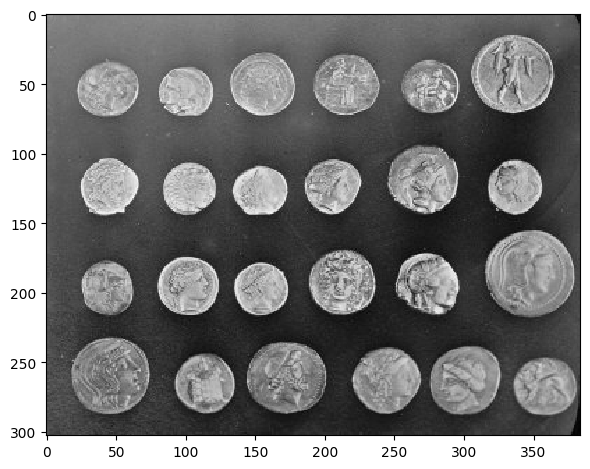

M = 384 columns, N = 303 rows
MIN = 1
MAX = 252


In [3]:
import skimage as sk
import numpy as np

I = sk.data.coins()
sk.io.imshow(I)
sk.io.show()

print('M = {} columns, N = {} rows'.format(I.shape[1], I.shape[0]))
print('MIN = {}'.format(I.min()))
print('MAX = {}'.format(I.max()))

**2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.**

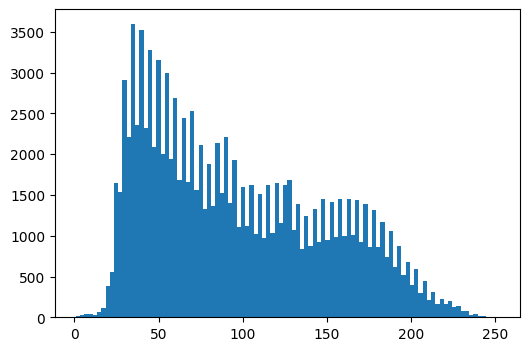

In [4]:
import matplotlib.pyplot as plt

flat_data = I.flatten()
fig = plt.figure(figsize=(6,4), dpi= 100, facecolor='w', edgecolor='k')
n = plt.hist(flat_data,bins=100,range=[1,flat_data.max()])
plt.show()

The peaks at lower grayscale values are related mainly to the dark background of the image. The peaks at medium and higher grayscale values are mostly related to the coins, because the coins appear brighter than the background. The highest intensity values may correspond to very bright areas on the coins, such as highlights.

**3. Applied noise to the image and use the correct function to erase the noise.**

/tmp/ipykernel_7447/2772538985.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.imshow(I_noise)
/tmp/ipykernel_7447/2772538985.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.show()


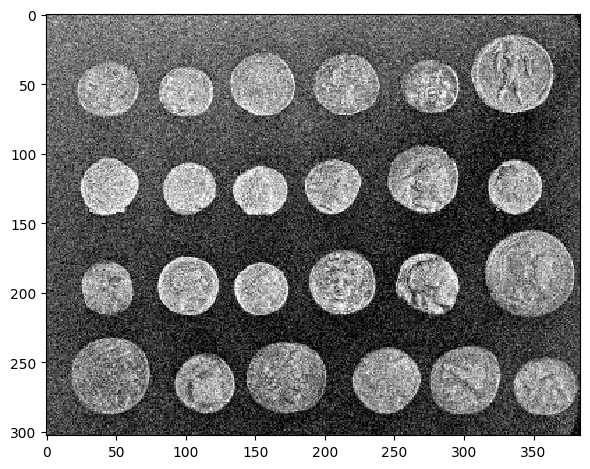

In [5]:
import skimage as sk

I_noise = sk.util.random_noise(I, mode='gaussian')
sk.io.imshow(I_noise)
sk.io.show()

/tmp/ipykernel_7447/4284555370.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.imshow(I_filtered)
/tmp/ipykernel_7447/4284555370.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.show()


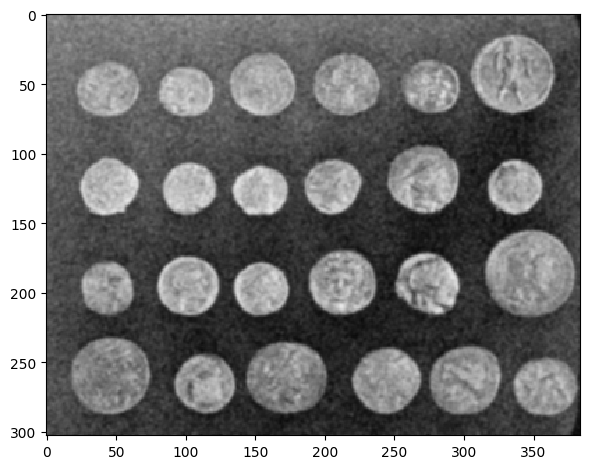

In [6]:
import skimage as sk

I_filtered = sk.filters.gaussian(I_noise, sigma=1)
sk.io.imshow(I_filtered)
sk.io.show()

Gaussian noise adds random intensity variations to the image. To reduce this type of noise, a Gaussian filter is used. The new filtered image becomes smoother, and part of the noise is removed, but some details and edges of the coins may also become slightly blurred.


**4. Segment the image using a k-means clustering algorithm with k=2 and represent the result**

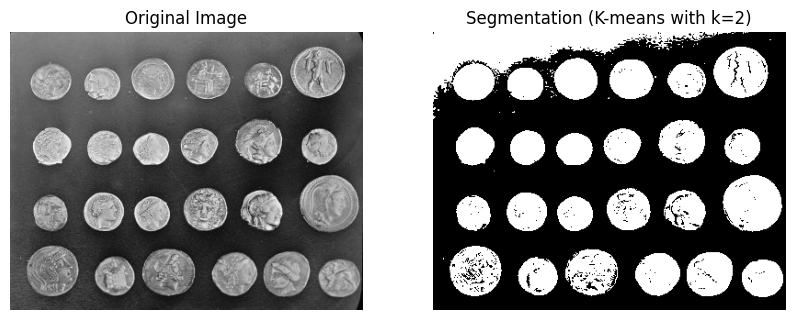

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
import numpy as np

v_I = I.reshape(I.shape[0]*I.shape[1],1).astype(np.uint8)

n_clus = 2
kmeans = KMeans(n_clusters=n_clus, random_state=0).fit(v_I)

v_kmeans = kmeans.predict(v_I)
I_kmeans = np.reshape(v_kmeans,(I.shape[0],I.shape[1]))

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(I, cmap=plt.cm.gray)
ax1.set_title('Original Image')
ax1.set_axis_off()

ax2 = fig.add_subplot(gs[0,1])
ax2.imshow(I_kmeans, cmap=plt.cm.gray)
ax2.set_title('Segmentation (K-means with k={})'.format(n_clus))
ax2.set_axis_off()

plt.show()

Since k = 2, the result contains two classes: one corresponding to the darker background and one corresponding to the brighter coins.
The segmentation detects most of the coin regions correctly because the coins are generally brighter than the background. However, some parts inside the coins are not completely segmented because the coins contain darker smaller details and shadows. Meaning some background pixels may also be assigned to the coin cluster if their intensity is similar to the coins.
Conclusion: K-Means gives an unsupervised segmentation of the coins, but the result is not perfect because it only uses pixel intensity similarity and does not use any ground truth or shape information.

**5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?**

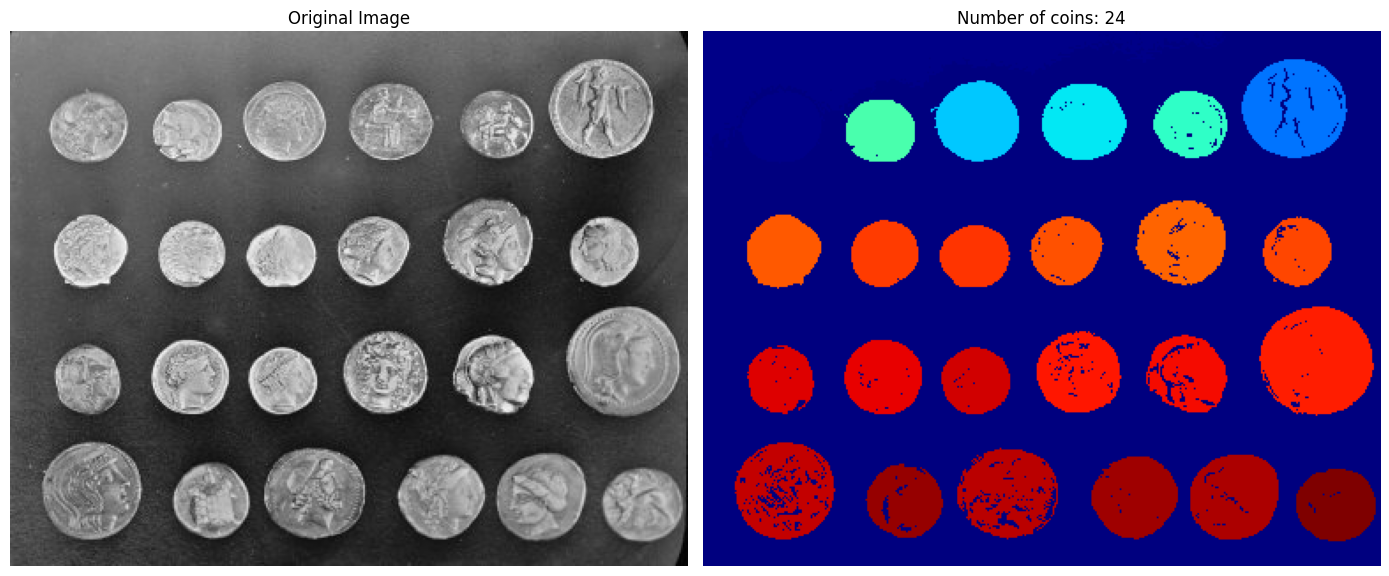

The number of coins is 24


In [8]:
from skimage.measure import label
from skimage.measure import regionprops
from skimage.color import label2rgb
import matplotlib.pyplot as plt
import numpy as np

label_image, nregions = label(I_kmeans,return_num=True)

props = regionprops(label_image)
area = np.zeros(nregions)
for i in range(0,nregions):
    area[i] = props[i].area

ind_small = np.where(area < 500)

for i in np.squeeze(ind_small):
    iregion = i+1
    label_image[label_image==iregion]=0

props = regionprops(label_image)
image_label_overlay = label2rgb(label_image, image=I)

fig, axes = plt.subplots(1,2,figsize=(14, 9))
ax = axes.ravel()
ax[0].imshow(I,cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[1].imshow(label_image,cmap=plt.cm.jet)
ax[1].set_title('Number of coins: {}'.format(len(props)))

ax[0].set_axis_off()
ax[1].set_axis_off()
plt.tight_layout()
plt.show()

print('The number of coins is {}'.format(len(props)))

**6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length.**

Average area = 1870.5833333333333 pixels
Average major axis length = 57.02381123599948 pixels
Average orientation = 0.07224453160752442


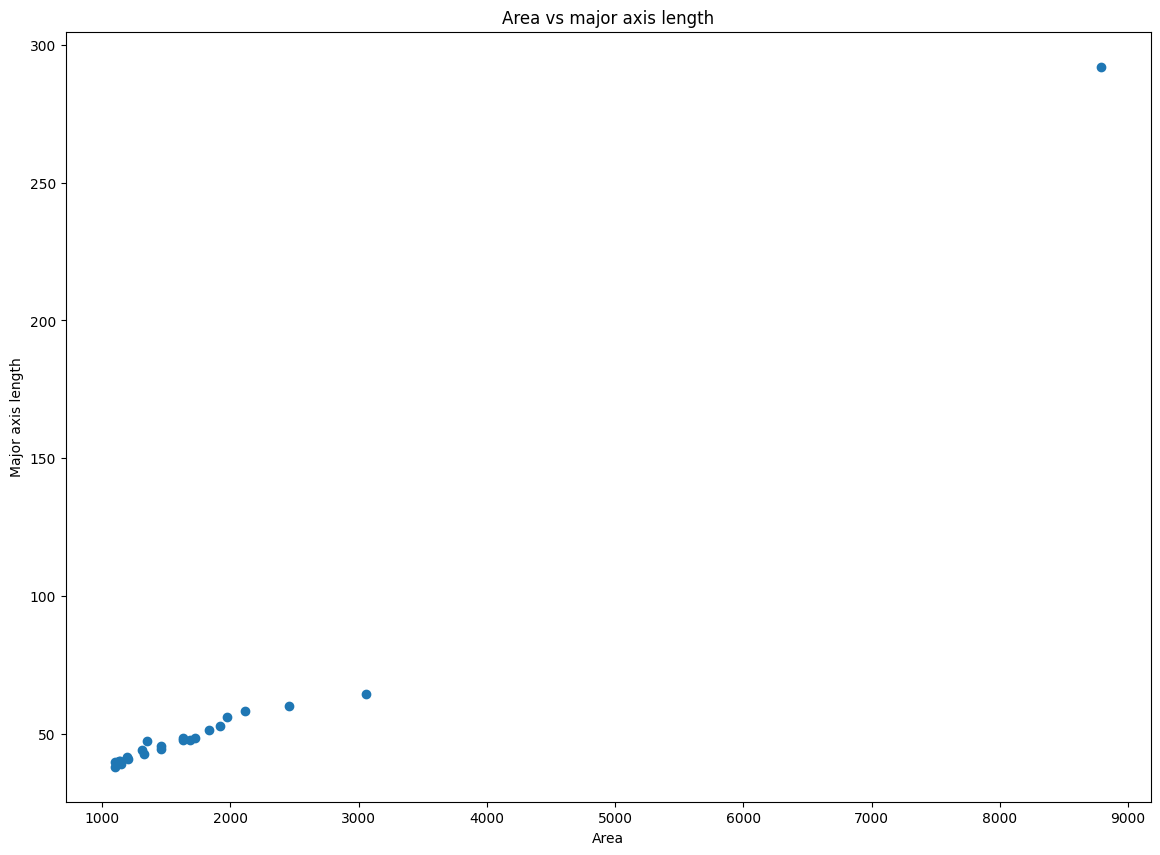

In [10]:
from skimage.measure import regionprops
import numpy as np
import matplotlib.pyplot as plt

props = regionprops(label_image)

ncoins = len(props)

area = np.zeros(ncoins)
major_axis_length = np.zeros(ncoins)
orientation = np.zeros(ncoins)

for i in range(0,ncoins):
    area[i] = props[i].area
    major_axis_length[i] = props[i].major_axis_length
    orientation[i] = props[i].orientation

print('Average area = {} pixels'.format(np.mean(area)))
print('Average major axis length = {} pixels'.format(np.mean(major_axis_length)))
print('Average orientation = {}'.format(np.mean(orientation)))

fig = plt.figure(figsize=(14,10))
plt.scatter(area, major_axis_length)
plt.xlabel('Area')
plt.ylabel('Major axis length')
plt.title('Area vs major axis length')
plt.show()

Important to note: One object falls under a much larger area and axis length than the rest. This is caused maybe by the incorrect labelling of one of the coins, which might appear due to overlapping or by being consideribly bigger than the rest.

**7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?**

In [11]:
from skimage.measure import regionprops
import numpy as np

props = regionprops(label_image)
ncoins = len(props)
area = np.zeros(ncoins)
for i in range(0,ncoins):
    area[i] = props[i].area

ind_large = np.where(area > 1750)
area_large = area[ind_large]

print('There are {} coins with area greater than 1750 pixels'.format(len(area_large)))
print('The areas of these coins are: {}'.format(area_large))

There are 7 coins with area greater than 1750 pixels
The areas of these coins are: [8792. 2459. 1836. 3062. 2111. 1971. 1918.]


**8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).**

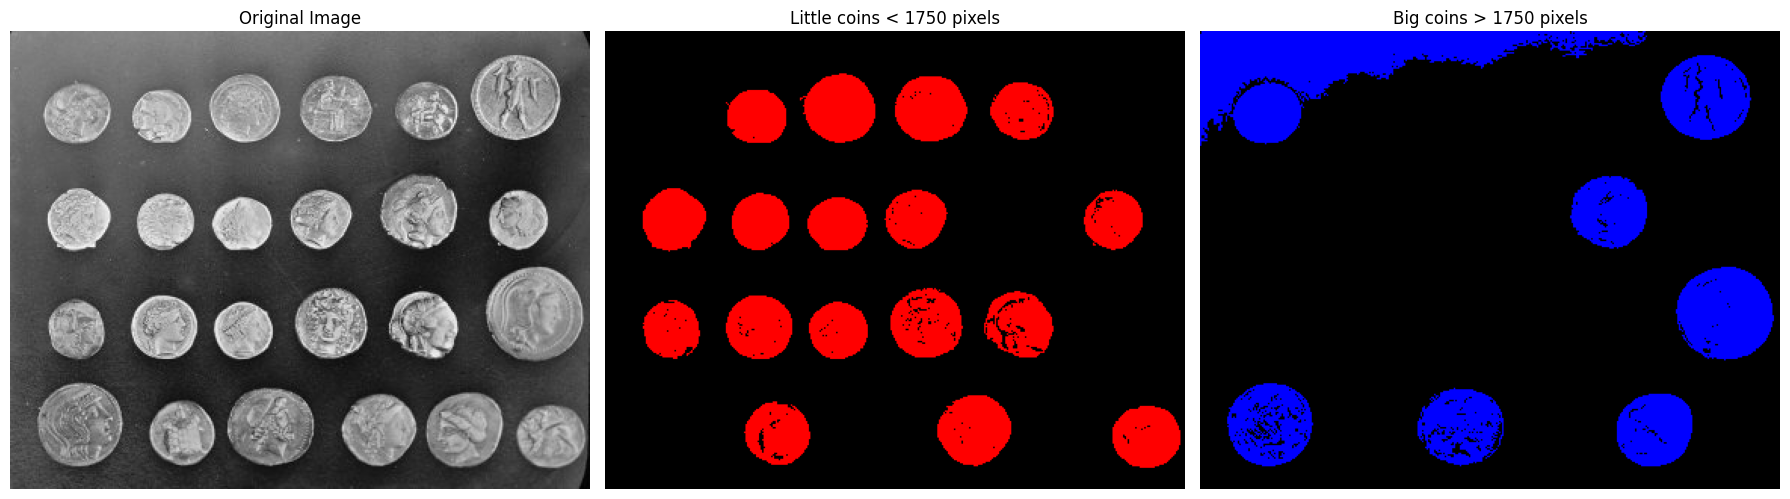

There are 17 little coins
There are 7 big coins


In [12]:
from skimage.measure import regionprops
import numpy as np
import matplotlib.pyplot as plt

props = regionprops(label_image)
ncoins = len(props)
area = np.zeros(ncoins)
regions = np.zeros(ncoins)

for i in range(0,ncoins):
    area[i] = props[i].area
    regions[i] = props[i].label

ind_small = np.where(area < 1750)
area_small = area[ind_small]
regions_small = regions[ind_small]

ind_large = np.where(area > 1750)
area_large = area[ind_large]
regions_large = regions[ind_large]

I_small = np.zeros((I.shape[0],I.shape[1],3),dtype=np.uint8)
I_large = np.zeros((I.shape[0],I.shape[1],3),dtype=np.uint8)

for i in np.squeeze(regions_small):
    I_small[label_image==i,0]=255

for i in np.squeeze(regions_large):
    I_large[label_image==i,2]=255

fig, axes = plt.subplots(1,3,figsize=(18, 9))
ax = axes.ravel()

ax[0].imshow(I,cmap=plt.cm.gray)
ax[0].set_title('Original Image')

ax[1].imshow(I_small)
ax[1].set_title('Little coins < 1750 pixels')

ax[2].imshow(I_large)
ax[2].set_title('Big coins > 1750 pixels')

ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()

plt.tight_layout()
plt.show()

print('There are {} little coins'.format(len(area_small)))
print('There are {} big coins'.format(len(area_large)))

** 9. Describe the main steps required to perform segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)**

In [19]:
import skimage as sk
import numpy as np

I = sk.data.coins()
v_I = np.reshape(I,(I.shape[0]*I.shape[1],1))

print('Here N = {} and d = {}'.format(I.shape[0]*I.shape[1],1))
print('The shape of the array should be {} x {}'.format(I.shape[0]*I.shape[1],1))

v_I.shape

Here N = 116352 and d = 1
The shape of the array should be 116352 x 1


(116352, 1)

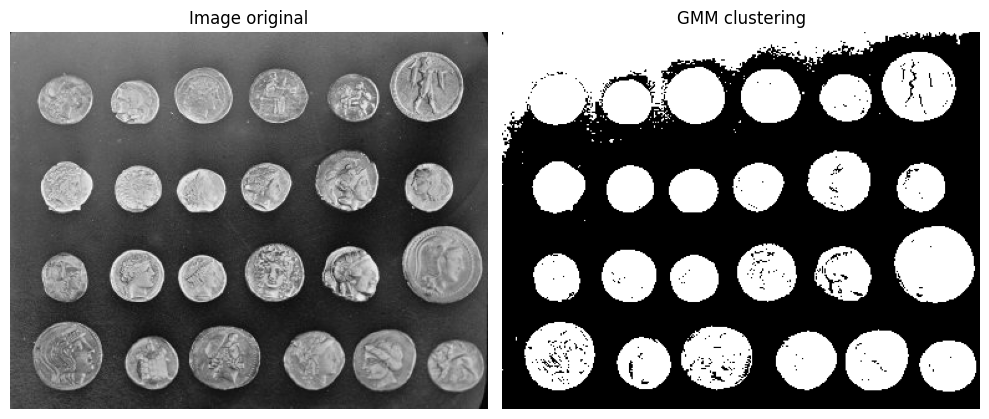

In [20]:
import skimage as sk
import numpy as np
from sklearn import mixture
import matplotlib.pyplot as plt
from matplotlib import gridspec

gmm = mixture.GaussianMixture(n_components=2).fit(v_I)
v_gmm = gmm.fit_predict(v_I)
I_gmm = np.reshape(v_gmm,(I.shape[0],I.shape[1]))

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(1, 2)

ax0 = fig.add_subplot(gs[0,0])
ax0.imshow(I, cmap=plt.cm.gray)
ax0.set_title('Image original')
ax0.set_axis_off()

ax1 = fig.add_subplot(gs[0,1])
ax1.imshow(I_gmm, cmap=plt.cm.gray)
ax1.set_title('GMM clustering')
ax1.set_axis_off()

plt.tight_layout()
plt.show()

[np.float64(1253590.5381016051)]
[np.float64(1253590.5381016051), np.float64(1225710.2884787596)]
[np.float64(1253590.5381016051), np.float64(1225710.2884787596), np.float64(1218941.6230613235)]
[np.float64(1253590.5381016051), np.float64(1225710.2884787596), np.float64(1218941.6230613235), np.float64(1216718.8722747427)]
[np.float64(1253590.5381016051), np.float64(1225710.2884787596), np.float64(1218941.6230613235), np.float64(1216718.8722747427), np.float64(1216202.829099414)]
[np.float64(1253590.5381016051), np.float64(1225710.2884787596), np.float64(1218941.6230613235), np.float64(1216718.8722747427), np.float64(1216202.829099414), np.float64(1215359.656635101)]
[np.float64(1253590.5381016051), np.float64(1225710.2884787596), np.float64(1218941.6230613235), np.float64(1216718.8722747427), np.float64(1216202.829099414), np.float64(1215359.656635101), np.float64(1215179.1793870395)]
[np.float64(1253590.5381016051), np.float64(1225710.2884787596), np.float64(1218941.6230613235), np.fl

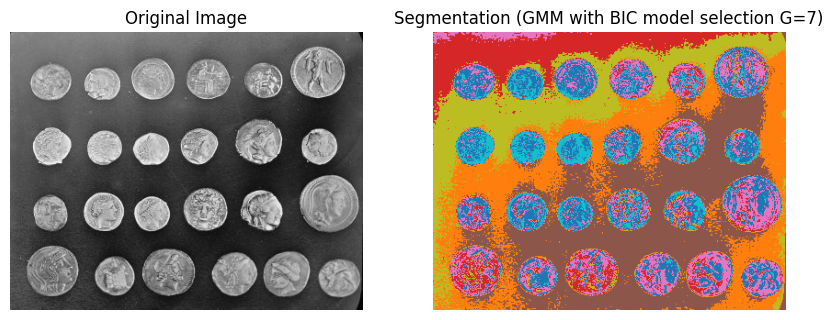

In [21]:
from sklearn.datasets import make_blobs
import numpy as np
from sklearn import mixture

NMAX = 10
bic = []
for kG in np.arange(1,NMAX+1):
    gmm = mixture.GaussianMixture(n_components=kG,covariance_type='full').fit(v_I)
    bic.append(gmm.bic(v_I))
    print(bic)

idx_winner = np.argmin(bic)
print('...and the winner is GMM model G = {}'.format(idx_winner+1))
gmm_win = mixture.GaussianMixture(n_components=idx_winner+1,covariance_type='full').fit(v_I)

import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

v_gmm = gmm_win.fit_predict(v_I)
I_gmm_bic = np.reshape(v_gmm,(I.shape[0],I.shape[1]))

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(I, cmap=plt.cm.gray)
ax1.set_title('Original Image')
ax1.set_axis_off()

ax2 = fig.add_subplot(gs[0,1])
ax2.imshow(I_gmm_bic, cmap=plt.cm.tab10)
ax2.set_title('Segmentation (GMM with BIC model selection G={})'.format(idx_winner+1))
ax2.set_axis_off()

plt.show()


To segment an RGB image with an unsupervised method, first we reshape the image. Each pixel becomes one observation, and the RGB values become the features.
After that, we apply a clustering method. Instead of K-Means, we can use GMM. GMM groups pixels according to their RGB values and assigns each pixel to one cluster. Then, the result is reshaped back to the original image size to visualize the segmentation.

If we choose a fixed GMM, we decide the number of components manually, for example 3 components. If we use GMM with BIC, the algorithm tests different numbers of components and chooses the best one automatically.

Compared to K-Means, GMM is more flexible because it uses Gaussian distributions instead of only distances to centroids. However, both methods are unsupervised, so the clusters are based only on color similarity and may not always correspond to real objects.

**10. Extract the main texture features of this image**

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.feature.texture import graycomatrix, graycoprops
from skimage.measure import regionprops

props = regionprops(label_image,intensity_image=I)
nregions = len(props)

iregion = 0
props_texture = np.zeros((nregions,5))
for p in props:
    minr, minc, maxr, maxc = p.bbox
    I_region = I[minr:maxr,minc:maxc]
    g = graycomatrix(I_region, [1], [0], levels=None, normed=True, symmetric=True)
    contrast = graycoprops(g, 'contrast')
    dissimilarity = graycoprops(g, 'dissimilarity')
    homogeneity = graycoprops(g, 'homogeneity')
    energy = graycoprops(g, 'energy')
    correlation = graycoprops(g, 'correlation')

    props_texture[iregion,0] = contrast
    props_texture[iregion,1] = dissimilarity
    props_texture[iregion,2] = homogeneity
    props_texture[iregion,3] = energy
    props_texture[iregion,4] = correlation

    iregion = iregion + 1

df = pd.DataFrame(props_texture, columns=['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation'])
df.to_excel("Texture_features.xlsx", index=False)
df

/tmp/ipykernel_7447/4103869692.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion,0] = contrast
/tmp/ipykernel_7447/4103869692.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion,1] = dissimilarity
/tmp/ipykernel_7447/4103869692.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  props_texture[iregion,2] = homogeneity
/tmp/ipykernel_7447/4103869692.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a s

,Contrast,Dissimilarity,Homogeneity,Energy,Correlation
0,254.474130,7.573417,0.310996,0.033827,0.890400
1,995.526634,21.321429,0.086937,0.017297,0.765693
2,529.480035,13.988465,0.120241,0.023318,0.815702
3,577.133102,16.666007,0.083029,0.020208,0.784722
4,1028.797176,21.617458,0.076587,0.021379,0.736437
5,595.839560,15.282784,0.098988,0.025766,0.798615
6,891.572083,19.571250,0.075520,0.018196,0.845380
7,784.764808,17.322300,0.097732,0.022090,0.857712
8,1067.844278,20.778612,0.072951,0.021424,0.832012
9,948.079605,18.903289,0.085836,0.023050,0.873162


Personal discussion
Provide a thoughtful reflection on the Computer Vision course, including your perspective on the knowledge you have acquired and your opinion about the professor. (Thank you very much for your feedback!)

I really enjoyed the course since it's quite different from what we've donw til now. I didnt spend too much time learning at home since the logic and theory behind the code was easy to understand during the lectures. All in all i think i would like to continue to check more of Computer Vision on my own since it represents a field im interested in for the future.
The only downside, is that the course is planned at the end of the semester, a period on wich we have a lot to do, and i wish i could've spent some more time to practice with newer concepts and methodologies.
Thank you Prof. Christian! I had a very insightful time with your course.
